# Localization

In [22]:
%reset -f
%run pylib/tools dark
from pylib.tools import np, plt
from utilities.ipynb_docgen import capture_hide, show
from importlib import reload
from like3 import likelihood as lk; reload(lk);
from like3.sourcelist import SourceList
from like3 import bands as bd; reload(bd)
from like3.bands import Band, BandList


In [23]:

bl = BandList.psf_demo()
self = lk.Likelihood(model=bl, data=bl.simulate(42))
with capture_hide("Fit results") as cap:
    self.maximize() 
    for key in self.fit_info.keys():
        if key!='cov':  print(f'{key}: {str(self.fit_info[key])}')
show(cap)

Model: 2 sources, 4 free parameters
Creating BandList with PSF for model: 2 sources, 4 free parameters
Counts per band: [6488 5357 4196 2951 1877  984  399  122   36   15    8    4]


TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

In [4]:
idx = 2
show(f"""#### With band {(band:=bl[idx])}, flux prediction and simulated counts""")
exposure = bl.exposure_factor[idx]

fig = plt.figure(figsize=(10,4))
sfig1, sfig2 = fig.subfigures(1,2)

band.plot_pixel_map(center=(2.5,0),  size=20, title='Flux prediction', fig=sfig1)
data = band.simulate( exposure=exposure, random_state=42)
band.plot_pixel_map(center=(2.5,0), data=data, size=20, title='Simulated Counts', fig=sfig2)
plt.show()    


show(f"""## Gradient evaluation""")
self = band

g = band.pixel_gradient( data, )
print('g shape:', g.shape)

NameError: name 'bl' is not defined

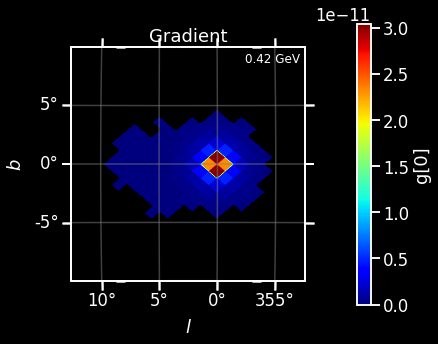

In [ ]:
band.plot_pixel_map(center=(2.5,0), data=dict(zip(data[0], g[:,0])), size=20, log=False, 
                    label='g[0]',title='Gradient')

In [ ]:
show(f"""## Full simulation""")
random_state = 42
self = bl
sim_data = dict()
for band, exposure in zip(self, self.exposure_factor):
    k,v = band.simulate(exposure=exposure, random_state=random_state)
    sim_data[int(band.energy)] = (k,v)

pixcnt = np.array([len(b) for k,b in sim_data.values()])
print(f'Pixels per band: {pixcnt}, total: {pixcnt.sum()}')

## Full simulation

Pixels per band: [ 45  68 111 149 165 162  69  27  22  18   4   7], total: 847


In [ ]:
bl.simulate()

array([7957, 6018, 4303, 3149, 1897, 1018,  430,  130,   42,   24,   13,    6])

In [ ]:
def pixel_flux(self):
    """ Convert flux to counts per pixel using the exposure factor for each band
    """
    r = dict()
    for band in self:
        r[int(band.energy)] = band.pixel_flux()
    return r

pf = pixel_flux(self)
print(f"""Number of pixels per band: {[len(v[0]) for v in pf.values()]}, total: {sum([len(v[0]) for v in pf.values()])}""")

Number of pixels per band: [45, 73, 122, 181, 257, 403, 191, 95, 182, 435, 376, 429], total: 2789


In [ ]:
class BandExposure:  
    """ Class to set up exposure generation for each band
    """      
    def __init__(self, band):
            self.band = band
            
    def __call__(self, pixel):

        pass

    @classmethod
    def demo(cls, band):
        """ Demo of the BandExposure class for a single band
        """
        self = cls(band)
        pixel = band.pixels[0]
        return self(pixel)


class Exposure:
    """ Class to set up exposure generation for each band
    """

    def __init__(self, bands):
        """ Initialize the Exposure class with a list of bands
        """
        for band in bands:
             band

    def __call__(self, band)
        """ Return an exposure class object that returns the exposure for a set of pixels in a band

        """
        return self.BandExposure(band)
        